# 06 · Prompted Reasoning — reasoning as a measured variable

Prompting "tricks" are usually argued by vibes. Here we **measure** them: a small reasoning-eval harness scores prompting strategies on a fixed set of multi-step word problems, so we can see exactly what each one buys — and what it costs.

1. **Direct** (answer-only) vs **chain-of-thought** (CoT).
2. **Few-shot CoT** — worked examples to control format and cost.
3. **Self-consistency** — sample several chains and vote.
4. **Cost** — accuracy is not free; CoT is *test-time compute* paid in tokens and latency.

Reusable code: `llmlab/evals/{tasks,prompts,extract,harness}.py`; tests: `tests/test_evals.py`. The same harness will back the agent and memory evals later in the lab."

In [ ]:
import sys
from pathlib import Path

LLM_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(LLM_DIR) not in sys.path:
    sys.path.insert(0, str(LLM_DIR))

import warnings
warnings.filterwarnings("ignore")
import transformers
transformers.logging.set_verbosity_error()

import pandas as pd
import matplotlib.pyplot as plt

from llmlab import config
from llmlab.models.local_model import LocalModel, SamplingConfig
from llmlab.evals.tasks import GSM_TASKS, FEWSHOT_EXEMPLARS
from llmlab.evals.prompts import direct_messages, cot_messages, fewshot_cot_messages
from llmlab.evals.harness import evaluate, self_consistency

config.configure_caches()
config.ensure_dirs()
config.seed_everything(0)
print("device:", config.get_device(), "| tasks:", len(GSM_TASKS))

device: mps | tasks: 14


## 1. Reasoning as a measured variable

The harness separates four concerns so each is swappable and testable:

- **tasks** — fixed problems with known integer answers (`evals/tasks.py`),
- **strategy** — a function `question -> chat messages` (`evals/prompts.py`),
- **extraction** — pull the final number from free-form text, preferring an explicit "the answer is N" over intermediate steps (`evals/extract.py`),
- **scoring** — accuracy plus token/latency cost (`evals/harness.py`).

Below: a few tasks, and the *same* question rendered under three strategies.

In [ ]:
lm = LocalModel("Qwen/Qwen2.5-0.5B-Instruct", dtype="float32", attn_implementation="sdpa")

print("Sample tasks:")
for t in GSM_TASKS[:3]:
    print(f"  [{t.id}] ({t.category}) {t.question}  ->  {t.answer}")

def show(messages):
    for m in messages:
        text = m["content"].replace("\n", " ")
        print(f"  {m['role']:9s}| {text[:78]}")

q = GSM_TASKS[2].question
print("\nDIRECT prompt:");            show(direct_messages(q))
print("\nCoT prompt:");               show(cot_messages(q))
print("\nFEW-SHOT CoT prompt:");       show(fewshot_cot_messages(q, FEWSHOT_EXEMPLARS))

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Sample tasks:
  [t01] (arithmetic) A baker bakes 24 muffins. He sells 9 in the morning and 7 in the afternoon. How many muffins are left?  ->  8
  [t02] (arithmetic) Tom buys 3 packs of pencils with 12 pencils in each pack. He gives 10 pencils to his friends. How many pencils does Tom have left?  ->  26
  [t03] (rates) A train travels at 60 km/h for 2 hours and then at 80 km/h for 1 hour. How many kilometers does it travel in total?  ->  200

DIRECT prompt:
  system   | You are a precise calculator. Give only the final number, with no words or wor
  user     | A train travels at 60 km/h for 2 hours and then at 80 km/h for 1 hour. How man

CoT prompt:
  system   | You are a careful problem solver. Work through the problem step by step, then 
  user     | A train travels at 60 km/h for 2 hours and then at 80 km/h for 1 hour. How man

FEW-SHOT CoT prompt:
  system   | You are a careful problem solver. Work through the problem step by step, then 
  user     | A shop has 15 red balloons and

## 2. Direct vs Chain-of-Thought

The cleanest experiment here. **Direct** forbids working ("reply with only the number"); **CoT** asks the model to think first. On multi-step problems a 0.5B model can't do the arithmetic in a single forward pass — so reasoning *space* is the difference between guessing and computing.

In [ ]:
direct = evaluate(lm, GSM_TASKS, direct_messages, "direct", SamplingConfig(max_new_tokens=16))
cot = evaluate(lm, GSM_TASKS, cot_messages, "CoT", SamplingConfig(max_new_tokens=256))

print(f"direct : acc={direct.accuracy:.0%}  tok/q={direct.avg_new_tokens:4.0f}  lat={direct.avg_latency_s:.2f}s")
print(f"CoT    : acc={cot.accuracy:.0%}  tok/q={cot.avg_new_tokens:4.0f}  lat={cot.avg_latency_s:.2f}s")

# A problem where forbidding reasoning is the difference:
for dr, cr in zip(direct.records, cot.records):
    if cr.correct and not dr.correct:
        question = next(t.question for t in GSM_TASKS if t.id == dr.task_id)
        print(f"\nExample [{dr.task_id}] (gold {dr.gold:.0f}): {question}")
        print(f"  direct -> {dr.output.strip()!r}  (pred {dr.pred})")
        print(f"  CoT    -> ...{cr.output.strip()[-150:]!r}  (pred {cr.pred})")
        break

direct : acc=21%  tok/q=   3  lat=0.12s
CoT    : acc=93%  tok/q= 184  lat=6.72s

Example [t01] (gold 8): A baker bakes 24 muffins. He sells 9 in the morning and 7 in the afternoon. How many muffins are left?
  direct -> '12'  (pred 12.0)
  CoT    -> ...'\nNext, subtract the muffins sold in the afternoon from the remaining muffins:\n\\[ 15 - 7 = 8 \\]\n\nSo, the number of muffins left is 8.\n\nThe answer is 8.'  (pred 8.0)


## 3. Few-shot CoT — format control and cost

Worked exemplars (supplied as prior user/assistant turns) teach the model a concise solution format. This tightens output and spends prompt tokens up front — and a terse induced format often trades a little accuracy for far fewer *generated* tokens. We measure both axes, not just accuracy.

In [ ]:
fewshot = evaluate(
    lm, GSM_TASKS,
    lambda q: fewshot_cot_messages(q, FEWSHOT_EXEMPLARS),
    "few-shot CoT", SamplingConfig(max_new_tokens=256),
)

df = pd.DataFrame([
    {"strategy": r.strategy, "accuracy": r.accuracy,
     "tokens_per_q": r.avg_new_tokens, "latency_s": r.avg_latency_s}
    for r in [direct, cot, fewshot]
])
df.round(3)

,strategy,accuracy,tokens_per_q,latency_s
0,direct,0.214,3.214,0.119
1,CoT,0.929,184.500,6.717
2,few-shot CoT,0.786,40.571,1.691


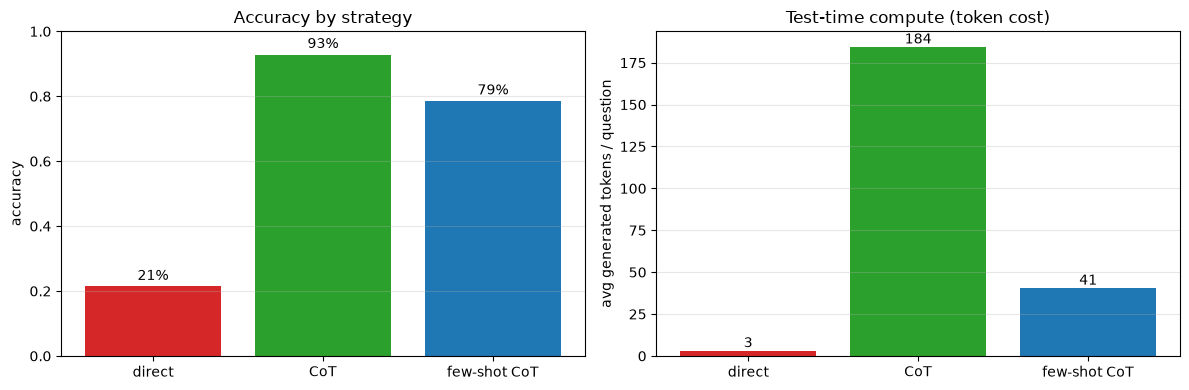

In [ ]:
colors = ["tab:red", "tab:green", "tab:blue"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(df.strategy, df.accuracy, color=colors)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("accuracy")
axes[0].set_title("Accuracy by strategy")
for i, v in enumerate(df.accuracy):
    axes[0].text(i, v + 0.02, f"{v:.0%}", ha="center")
axes[1].bar(df.strategy, df.tokens_per_q, color=colors)
axes[1].set_ylabel("avg generated tokens / question")
axes[1].set_title("Test-time compute (token cost)")
for i, v in enumerate(df.tokens_per_q):
    axes[1].text(i, v + 2, f"{v:.0f}", ha="center")
for ax in axes:
    ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 4. Self-consistency — sample many chains, then vote

A single greedy chain can take one wrong turn and commit to it. **Self-consistency** samples `k` independent chains (temperature > 0) and returns the majority answer — trading `k×` the compute for robustness. Its payoff is largest exactly where a single chain is unreliable; when greedy CoT is already strong, expect only a small gain. We run it on a subset (cost!) and inspect the vote distributions.

In [ ]:
subset = [GSM_TASKS[i] for i in (1, 5, 7, 8, 10, 12)]
subset_ids = {t.id for t in subset}

sc = self_consistency(lm, subset, cot_messages, k=5, max_new_tokens=220)
greedy_cot_acc = sum(r.correct for r in cot.records if r.task_id in subset_ids) / len(subset)

print(f"subset greedy-CoT accuracy        : {greedy_cot_acc:.0%}")
print(f"subset self-consistency (k=5)     : {sc.accuracy:.0%}\n")
for r in sc.records:
    flag = "ok " if r.correct else "MISS"
    print(f"  [{r.task_id}] gold={r.gold:5.0f}  vote={r.pred}  {flag}  {r.output}")

subset greedy-CoT accuracy        : 83%
subset self-consistency (k=5)     : 83%

  [t02] gold=   26  vote=26.0  ok   votes=[26.0, 26.0, 26.0, 26.0, 26.0]
  [t06] gold=   95  vote=105.0  MISS  votes=[105.0, 95.0, 7.0, 105.0, 15.0]
  [t08] gold=   30  vote=30.0  ok   votes=[30.0, 30.0, 30.0, 30.0, 30.0]
  [t09] gold=  150  vote=150.0  ok   votes=[150.0, 90.0, 2.0, 150.0, 150.0]
  [t11] gold=   16  vote=16.0  ok   votes=[16.0, 16.0, 16.0, 8.0, 16.0]
  [t13] gold=  198  vote=198.0  ok   votes=[90.0, 198.0, 198.0, 4.0, 198.0]


In [ ]:
# Where does CoT still fail? Read the model's own (wrong) reasoning.
wrong = [r for r in cot.records if not r.correct]
print(f"CoT got {len(cot.records) - len(wrong)}/{len(cot.records)} correct; failures below:\n")
for r in wrong:
    question = next(t.question for t in GSM_TASKS if t.id == r.task_id)
    print(f"[{r.task_id}] {question}")
    print(f"  gold={r.gold:.0f}  pred={r.pred}")
    print(f"  model: ...{r.output.strip()[-200:]!r}\n")

CoT got 13/14 correct; failures below:

[t06] A water tank holds 200 liters. It loses 15 liters per day. How many liters remain after 7 days?
  gold=95  pred=15.0
  model: ...'aining amount:\n\\[\n\\text{Remaining water} = \\text{Initial amount} - \\text{Total loss}\n\\]\n\\[\n\\text{Remaining water} = 200 \\, \\text{liters} - 105 \\, \\text{liters} = 95 \\, \\text{liters}\n\\]\n\nTherefore, the'



## 5. What this means for the lab

- **CoT is test-time compute.** It converts tokens and latency into accuracy — here a large jump for ~60× the tokens of direct answering. That trade is a *dial*; self-consistency turns it further (k× compute for robustness).
- **Few-shot controls format, not just accuracy.** Exemplars can slash generated tokens by inducing a terse style — sometimes the better operating point once cost matters.
- **Extraction is part of the experiment.** A chunk of "wrong" answers are really parse failures; the conclusion-cue parser earns its keep, and you must read raw outputs to tell the two apart.
- **This harness is the lab's measuring stick.** Every later claim — retrieval helps, a memory policy works, a fine-tune improved things — becomes an accuracy/cost delta on a harness exactly like this one (and reasoning is the scratchpad the agent in Notebook 07 will use).

In [ ]:
import json

summary = {
    "model": lm.model_id,
    "device": lm.device,
    "n_tasks": len(GSM_TASKS),
    "strategies": {
        r.strategy: {
            "accuracy": round(r.accuracy, 3),
            "avg_new_tokens": round(r.avg_new_tokens, 1),
            "avg_latency_s": round(r.avg_latency_s, 2),
        }
        for r in [direct, cot, fewshot]
    },
    "self_consistency_subset": {
        "n": sc.n,
        "k": 5,
        "accuracy": round(sc.accuracy, 3),
        "greedy_cot_subset_accuracy": round(greedy_cot_acc, 3),
    },
}
path = config.RESULTS_DIR / "06_prompted_reasoning.json"
path.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
print("\nwrote", path)

{
  "model": "Qwen/Qwen2.5-0.5B-Instruct",
  "device": "mps",
  "n_tasks": 14,
  "strategies": {
    "direct": {
      "accuracy": 0.214,
      "avg_new_tokens": 3.2,
      "avg_latency_s": 0.12
    },
    "CoT": {
      "accuracy": 0.929,
      "avg_new_tokens": 184.5,
      "avg_latency_s": 6.72
    },
    "few-shot CoT": {
      "accuracy": 0.786,
      "avg_new_tokens": 40.6,
      "avg_latency_s": 1.69
    }
  },
  "self_consistency_subset": {
    "n": 6,
    "k": 5,
    "accuracy": 0.833,
    "greedy_cot_subset_accuracy": 0.833
  }
}

wrote /Users/iali/workplace/projects/personal/ml-notes/docs/LLM/results/06_prompted_reasoning.json
